# 📉 Task 2 — Unemployment Analysis with Python
**CodeAlpha Data Science Internship**  
Intern: Asiedu Seth Osei | ID: CA/DF1/63603

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load & Merge Datasets

In [5]:
df1 = pd.read_csv('data/Unemployment_in_India.csv')
df2 = pd.read_csv('data/Unemployment_Rate_upto_11_2020.csv')

# Strip whitespace from column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print("── Dataset 1: Unemployment in India ──")
print(f"Shape: {df1.shape}")
print(df1.head(3))

── Dataset 1: Unemployment in India ──
Shape: (768, 7)
           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  


In [6]:
print("── Dataset 2: Unemployment Rate upto Nov 2020 ──")
print(f"Shape: {df2.shape}")
print(df2.head(3))

── Dataset 2: Unemployment Rate upto Nov 2020 ──
Shape: (267, 9)
           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020         M                             5.48   
1  Andhra Pradesh   29-02-2020         M                             5.83   
2  Andhra Pradesh   31-03-2020         M                             5.79   

   Estimated Employed  Estimated Labour Participation Rate (%) Region.1  \
0            16635535                                    41.02    South   
1            16545652                                    40.90    South   
2            15881197                                    39.18    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129     79.74  
2    15.9129     79.74  


In [7]:
# Standardise column names across both datasets
rename_map = {
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed':              'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation',
}
df1.rename(columns=rename_map, inplace=True)
df2.rename(columns=rename_map, inplace=True)

# Parse dates
df1['Date'] = pd.to_datetime(df1['Date'].str.strip(), dayfirst=True)
df2['Date'] = pd.to_datetime(df2['Date'].str.strip(), dayfirst=True)

print("✅ Dates parsed")
print(f"df1 date range: {df1['Date'].min().date()} → {df1['Date'].max().date()}")
print(f"df2 date range: {df2['Date'].min().date()} → {df2['Date'].max().date()}")

✅ Dates parsed
df1 date range: 2019-05-31 → 2020-06-30
df2 date range: 2020-01-31 → 2020-10-31


## 3. Exploratory Data Analysis

In [8]:
print("Missing values — Dataset 1:")
print(df1.isnull().sum())
print("\nMissing values — Dataset 2:")
print(df2.isnull().sum())

Missing values — Dataset 1:
Region                  28
Date                    28
Frequency               28
Unemployment_Rate       28
Employed                28
Labour_Participation    28
Area                    28
dtype: int64

Missing values — Dataset 2:
Region                  0
Date                    0
Frequency               0
Unemployment_Rate       0
Employed                0
Labour_Participation    0
Region.1                0
longitude               0
latitude                0
dtype: int64


In [9]:
print("Statistical Summary — Unemployment Rate:")
print(df1['Unemployment_Rate'].describe().round(2))

Statistical Summary — Unemployment Rate:
count    740.00
mean      11.79
std       10.72
min        0.00
25%        4.66
50%        8.35
75%       15.89
max       76.74
Name: Unemployment_Rate, dtype: float64


## 4. National Unemployment Trend

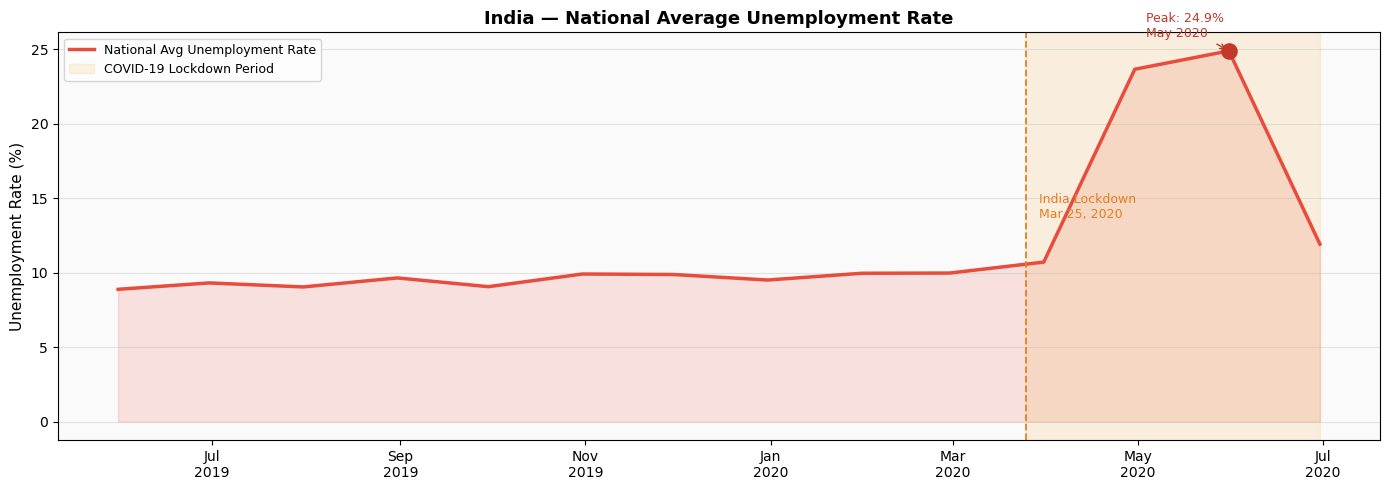

✅ Plot saved


In [10]:
national = df1.groupby('Date')['Unemployment_Rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(national['Date'], national['Unemployment_Rate'], alpha=0.15, color='#E74C3C')
ax.plot(national['Date'], national['Unemployment_Rate'],
        color='#E74C3C', linewidth=2.5, label='National Avg Unemployment Rate')

# COVID annotation
covid_start = pd.Timestamp('2020-03-25')
ax.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-06-30'),
           alpha=0.12, color='#F39C12', label='COVID-19 Lockdown Period')
ax.axvline(covid_start, color='#E67E22', linestyle='--', linewidth=1.3)
ax.annotate('India Lockdown\nMar 25, 2020',
            xy=(covid_start, national['Unemployment_Rate'].max()*0.55),
            xytext=(10,0), textcoords='offset points',
            fontsize=9, color='#E67E22')

# Peak annotation
peak = national.loc[national['Unemployment_Rate'].idxmax()]
ax.scatter(peak['Date'], peak['Unemployment_Rate'], color='#C0392B', s=120, zorder=5)
ax.annotate(f"Peak: {peak['Unemployment_Rate']:.1f}%\n{peak['Date'].strftime('%b %Y')}",
            xy=(peak['Date'], peak['Unemployment_Rate']),
            xytext=(-60, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='#C0392B'), fontsize=9, color='#C0392B')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.set_ylabel('Unemployment Rate (%)', fontsize=11)
ax.set_title('India — National Average Unemployment Rate', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.yaxis.grid(True, alpha=0.3); ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('./outputs/national_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved")

## 5. Regional Heatmap

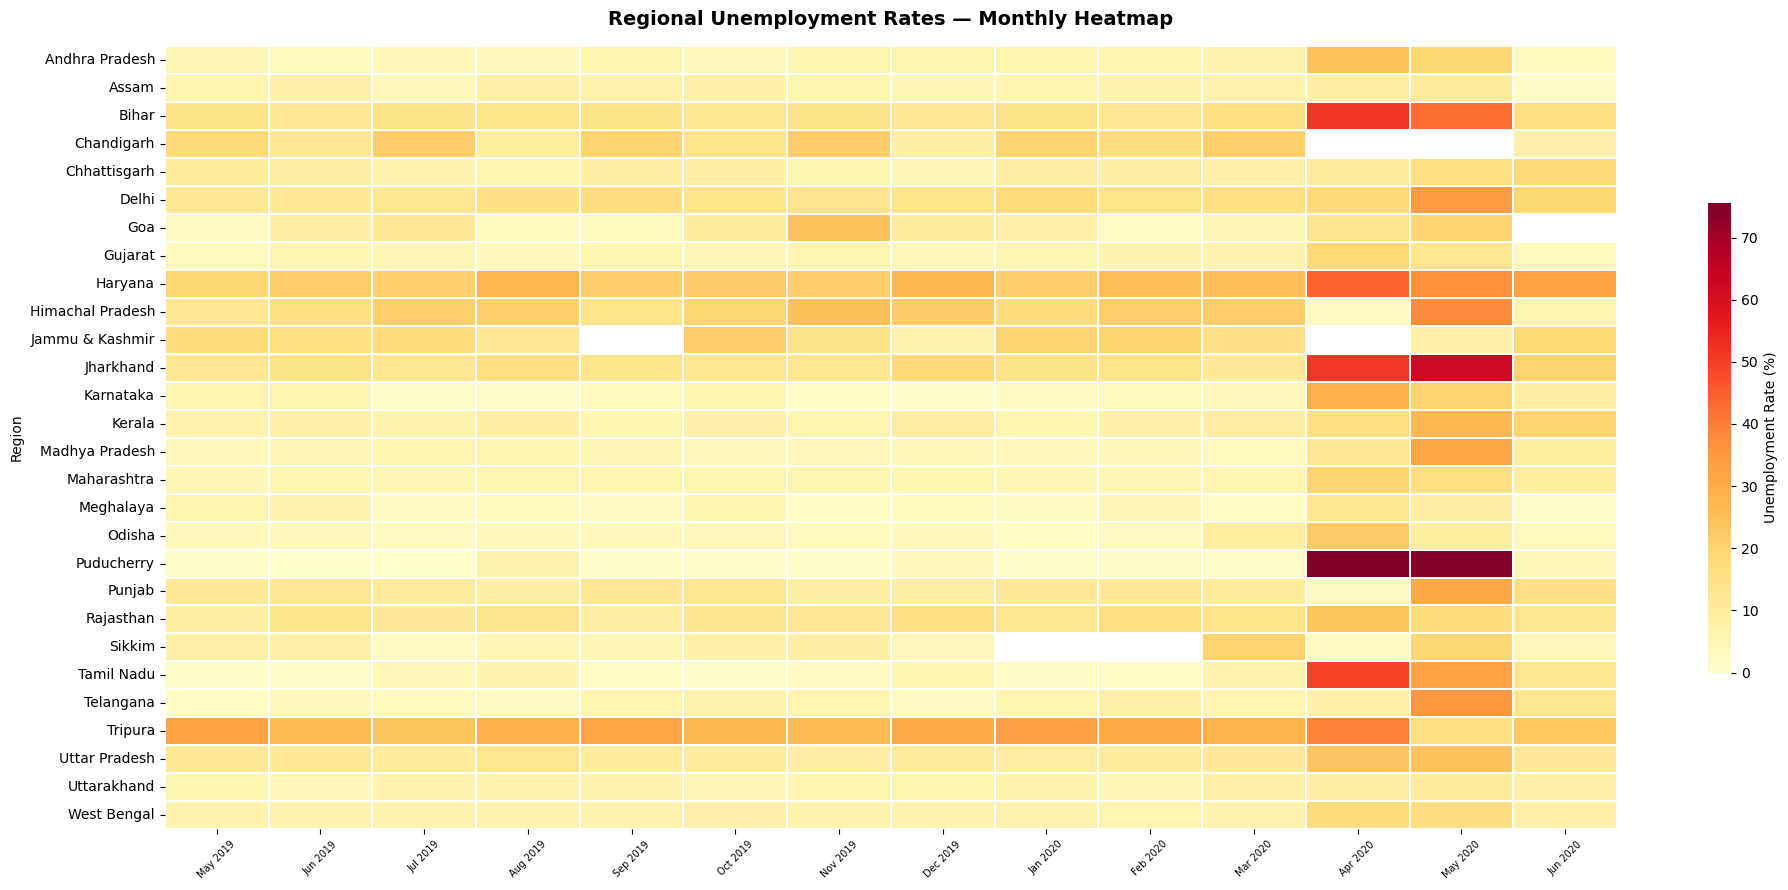

✅ Heatmap saved


In [11]:
pivot = df1.pivot_table(index='Region', columns='Date',
                        values='Unemployment_Rate', aggfunc='mean')
pivot.columns = [c.strftime('%b %Y') for c in pivot.columns]

fig, ax = plt.subplots(figsize=(20, 9))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Unemployment Rate (%)', 'shrink': 0.6})
ax.set_title('Regional Unemployment Rates — Monthly Heatmap', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.tight_layout()
plt.savefig('./outputs/regional_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved")

## 6. COVID-19 Impact Analysis

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


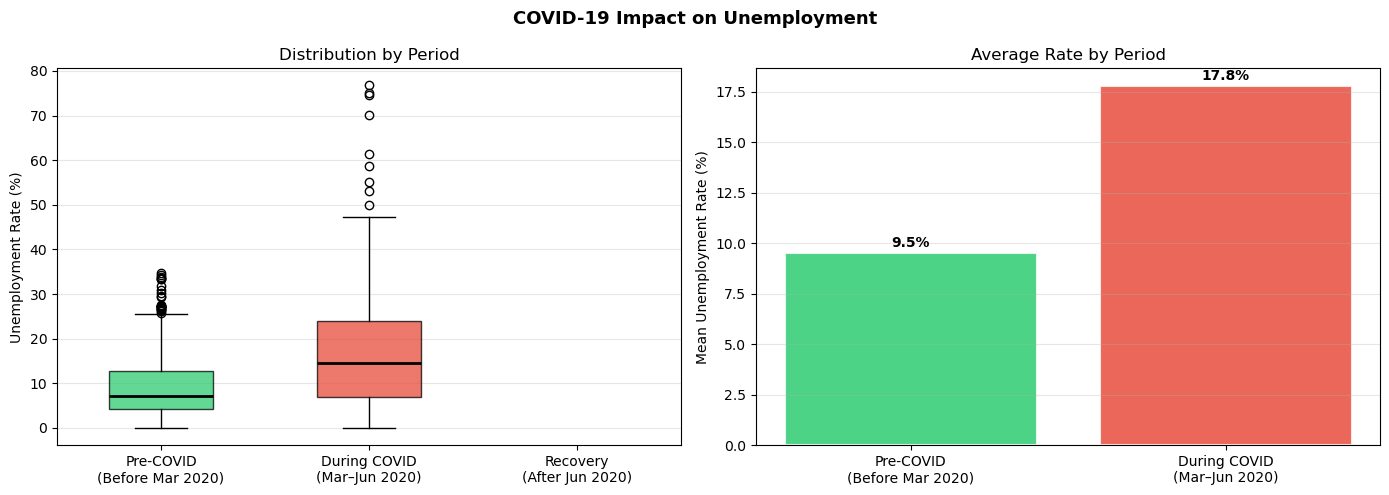

In [12]:
pre    = df1[df1['Date'] < '2020-03-01']['Unemployment_Rate']
during = df1[(df1['Date'] >= '2020-03-01') & (df1['Date'] <= '2020-06-30')]['Unemployment_Rate']
after  = df1[df1['Date'] > '2020-06-30']['Unemployment_Rate']

labels = ['Pre-COVID\n(Before Mar 2020)', 'During COVID\n(Mar–Jun 2020)', 'Recovery\n(After Jun 2020)']
data   = [pre.values, during.values, after.values]
colors = ['#2ECC71', '#E74C3C', '#3498DB']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('COVID-19 Impact on Unemployment', fontsize=13, fontweight='bold')

bp = axes[0].boxplot(data, patch_artist=True, labels=labels, widths=0.5,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0].set_ylabel('Unemployment Rate (%)'); axes[0].set_title('Distribution by Period')
axes[0].yaxis.grid(True, alpha=0.3)

means = [d.mean() for d in data]
bars  = axes[1].bar(labels, means, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, mean in zip(bars, means):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{mean:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Mean Unemployment Rate (%)'); axes[1].set_title('Average Rate by Period')
axes[1].yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Top Affected Regions

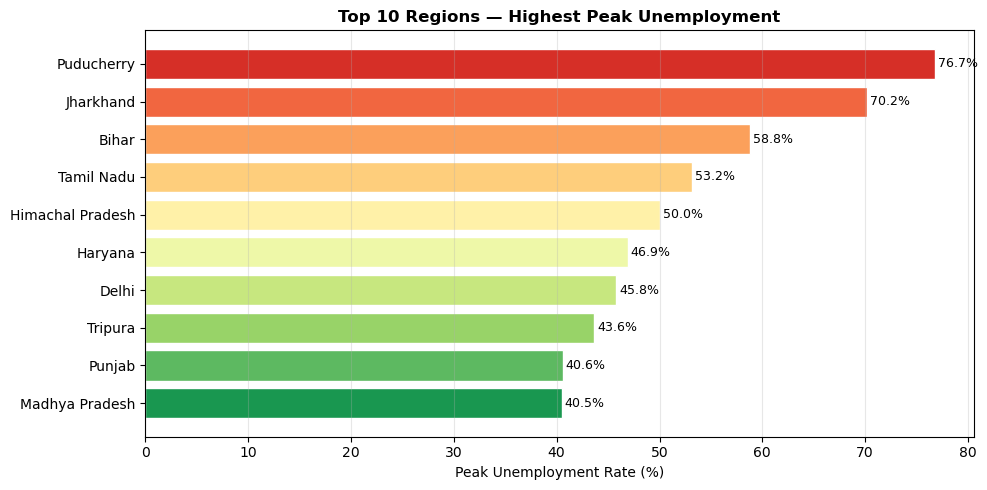

In [13]:
top10 = df1.groupby('Region')['Unemployment_Rate'].max().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10.index[::-1], top10.values[::-1],
               color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 10)), edgecolor='white')
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Peak Unemployment Rate (%)')
ax.set_title('Top 10 Regions — Highest Peak Unemployment', fontsize=12, fontweight='bold')
ax.xaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/top_regions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Urban vs Rural Comparison

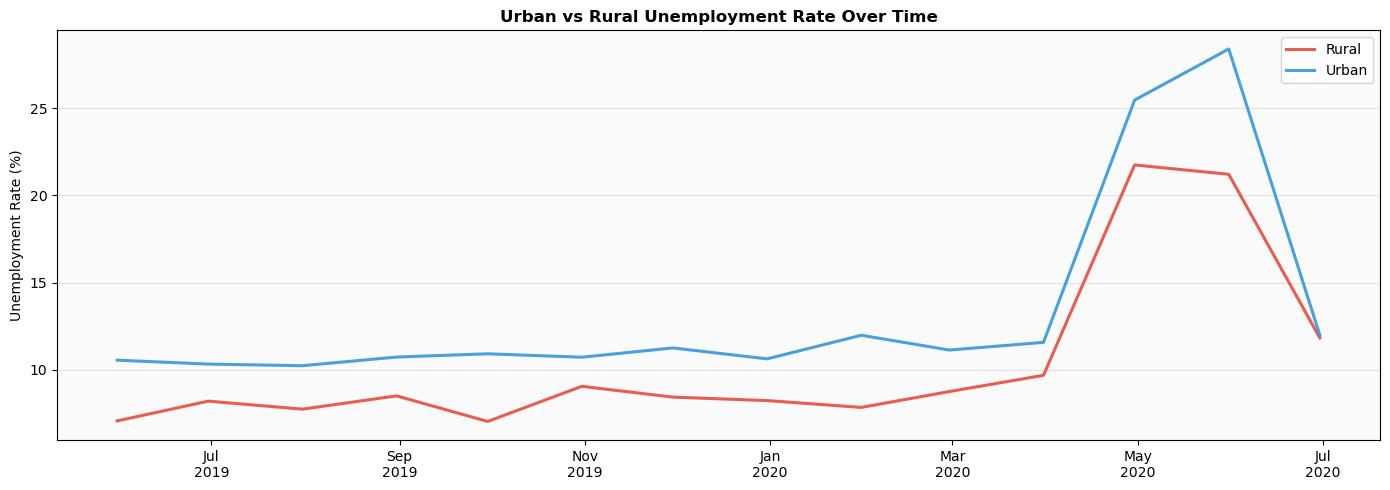

In [14]:
if 'Area' in df1.columns:
    area_monthly = df1.groupby(['Date','Area'])['Unemployment_Rate'].mean().unstack()
    fig, ax = plt.subplots(figsize=(14,5))
    for area, color in zip(area_monthly.columns, ['#E74C3C','#3498DB']):
        ax.plot(area_monthly.index, area_monthly[area], linewidth=2.2,
                color=color, label=area, alpha=0.9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.set_ylabel('Unemployment Rate (%)')
    ax.set_title('Urban vs Rural Unemployment Rate Over Time', fontsize=12, fontweight='bold')
    ax.legend(); ax.yaxis.grid(True, alpha=0.3); ax.set_facecolor('#FAFAFA')
    plt.tight_layout()
    plt.savefig('./outputs/urban_rural.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Area column not found in this dataset.")

## 9. Key Insights Summary

In [15]:
pre_mean    = pre.mean()
during_mean = during.mean()
after_mean  = after.mean()

print('=' * 55)
print('  KEY INSIGHTS — UNEMPLOYMENT ANALYSIS')
print('=' * 55)
print(f'  Pre-COVID avg rate      : {pre_mean:.2f}%')
print(f'  COVID peak avg rate     : {during_mean:.2f}%')
print(f'  Post-COVID recovery avg : {after_mean:.2f}%')
print(f'  COVID impact (increase) : +{during_mean - pre_mean:.2f} pp')
print(f'  Hardest hit region      : {top10.index[0]} @ {top10.iloc[0]:.2f}%')
print(f'  % recovered from peak   : {((during_mean-after_mean)/during_mean)*100:.1f}%')

  KEY INSIGHTS — UNEMPLOYMENT ANALYSIS
  Pre-COVID avg rate      : 9.51%
  COVID peak avg rate     : 17.77%
  Post-COVID recovery avg : nan%
  COVID impact (increase) : +8.26 pp
  Hardest hit region      : Puducherry @ 76.74%
  % recovered from peak   : nan%


---
## ✅ Task 2 Complete
**COVID-19 caused an unprecedented spike in unemployment across all Indian regions.**  
**GitHub:** `CodeAlpha_DataScience_Internship/Task2_Unemployment_Analysis/`